# Comparing named gold pressure scales

“A gold EOS” is not a unique calibration. Peritheos keeps literature scales
as named records with their own equations, reference states, validity ranges,
provenance, and uncertainty information. This notebook compares three Au
records without mixing those identities.

In [1]:
import matplotlib.pyplot as plt
import numpy as np

from peritheos import get_eos_record

plt.style.use("seaborn-v0_8-whitegrid")

scales = {
    "Sokolova 2016": get_eos_record("au_fcc_sokolova_2016"),
    "Fei 2007": get_eos_record("au_fcc_fei_2007"),
    "Dorfman 2012": get_eos_record("au_fcc_dorfman_2012"),
}

for label, scale in scales.items():
    print(f"{label}: {scale.identifier}")
    print(f"  DOI: {scale.reference.doi}")
    print(f"  validity: {scale.validity}")

Sokolova 2016: au_fcc_sokolova_2016
  DOI: 10.1016/j.cageo.2016.06.002
  validity: ValidityRange(pressure_gpa=(0.0, 400.0), temperature_k=(298.15, 3000.0), volume_ratio=None, notes=('Section 4 states the calculation range is at least 0-400 GPa and 298.15-3000 K; this is not a uniform experimental-data rectangle.', 'Equation 11 is discussed through compression V/V0 = 0.6, but no joint per-material volume limit is published.'))
Fei 2007: au_fcc_fei_2007
  DOI: 10.1073/pnas.0609013104
  validity: ValidityRange(pressure_gpa=(0.0, 125.0), temperature_k=(300.0, 2330.0), volume_ratio=None, notes=('Marginal envelope of the measurements and fitted curves in Figures 1-5; not every pressure-temperature combination was measured.',))
Dorfman 2012: au_fcc_dorfman_2012
  DOI: 10.1029/2012JB009292
  validity: ValidityRange(pressure_gpa=(1.0, 250.0), temperature_k=(300.0, 300.0), volume_ratio=None, notes=('Pressure range is the experimental run envelope in Table 1, limited to 250 GPa where the paper cl

## Compare the 300 K isotherms

All three records can be evaluated over the common range below. Their absolute
pressures are visually similar, so the lower panel plots each difference from
the Fei scale. The comparison uses the conventional fcc cell volume in
$\mathrm{\mathring{A}^3}$.

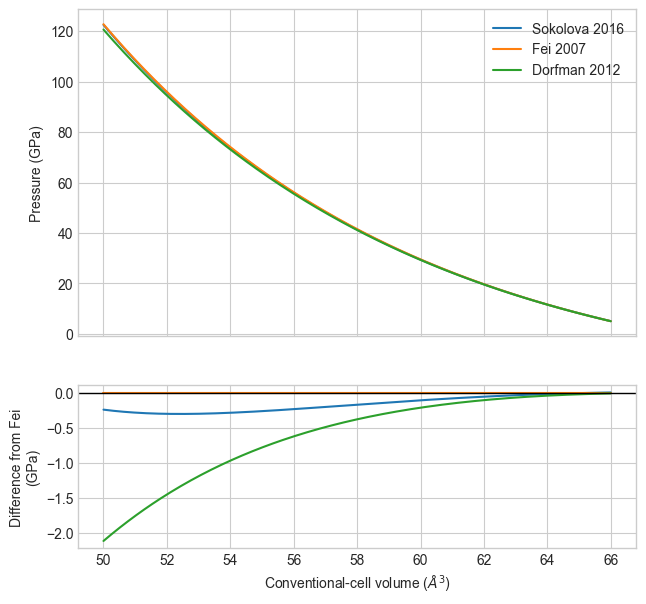

In [2]:
volume_300 = np.linspace(50.0, 66.0, 250)
pressure_300 = {
    label: scale.pressure(volume_300, 300.0) for label, scale in scales.items()
}
reference_300 = pressure_300["Fei 2007"]

fig, (ax_pressure, ax_difference) = plt.subplots(
    2, 1, figsize=(7.2, 7.0), sharex=True, height_ratios=(2.0, 1.0)
)
for label, pressure in pressure_300.items():
    ax_pressure.plot(volume_300, pressure, label=label)
    ax_difference.plot(volume_300, pressure - reference_300, label=label)

ax_pressure.set(ylabel="Pressure (GPa)")
ax_pressure.legend()
ax_difference.axhline(0.0, color="black", lw=1)
ax_difference.set(
    xlabel=r"Conventional-cell volume ($\AA^3$)",
    ylabel="Difference from Fei\n(GPa)",
)
plt.show()

## Compare thermal scales at 1800 K

The Dorfman record is a 300 K isotherm and has no thermal correction. Only the
Sokolova and Fei records are therefore scientifically eligible for this panel.
The volume range is chosen so both pressures remain inside the Fei record's
published 0–125 GPa envelope.

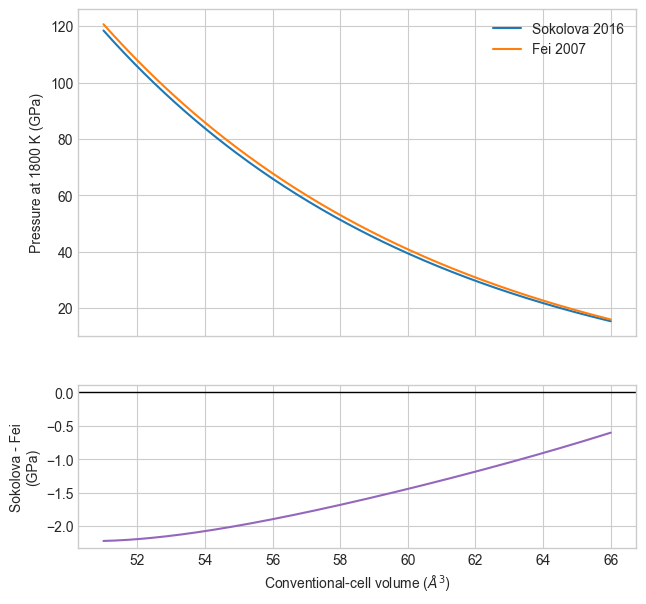

In [3]:
thermal_scales = {name: scales[name] for name in ("Sokolova 2016", "Fei 2007")}
volume_hot = np.linspace(51.0, 66.0, 250)
pressure_hot = {
    label: scale.pressure(volume_hot, 1800.0)
    for label, scale in thermal_scales.items()
}

fig, (ax_pressure, ax_difference) = plt.subplots(
    2, 1, figsize=(7.2, 7.0), sharex=True, height_ratios=(2.0, 1.0)
)
for label, pressure in pressure_hot.items():
    ax_pressure.plot(volume_hot, pressure, label=label)

ax_difference.plot(
    volume_hot,
    pressure_hot["Sokolova 2016"] - pressure_hot["Fei 2007"],
    color="tab:purple",
)
ax_pressure.set(ylabel="Pressure at 1800 K (GPa)")
ax_pressure.legend()
ax_difference.axhline(0.0, color="black", lw=1)
ax_difference.set(
    xlabel=r"Conventional-cell volume ($\AA^3$)",
    ylabel="Sokolova - Fei\n(GPa)",
)
plt.show()

## Compare uncertainty assumptions at one state

The numerical interval reflects both available source information and the
measurement errors supplied here. Fei reports parameter errors without a
covariance matrix; Sokolova reports no individual parameter errors. Peritheos
does not invent missing covariance or parameter uncertainty.

In [4]:
state = {"volume": 55.0, "temperature": 1800.0}
for label, scale in thermal_scales.items():
    prediction = scale.pressure_with_uncertainty(
        **state,
        volume_sigma=0.01,
        temperature_sigma=20.0,
    )
    print(
        f"{label:15s}: {prediction.value:7.3f} +/- "
        f"{prediction.standard_error:.3f} GPa"
    )
    for assumption in prediction.assumptions:
        print(f"  - {assumption}")

Sokolova 2016  :  74.423 +/- 0.161 GPa
  - published parameter uncertainty not available
  - local linear (delta-method) uncertainty propagation
  - state-variable errors treated as independent
Fei 2007       :  76.410 +/- 0.776 GPa
  - parameter errors treated as mutually independent
  - local linear (delta-method) uncertainty propagation
  - state-variable errors treated as independent


## Let record semantics prevent misuse

Passing 1800 K to the Dorfman isotherm raises an error rather than silently
pretending that its 300 K calibration has a thermal model.

In [5]:
try:
    scales["Dorfman 2012"].pressure(volume=55.0, temperature=1800.0)
except ValueError as error:
    print(type(error).__name__ + ":", error)

ValueError: au_fcc_dorfman_2012 is an isothermal 300 K EOS record and has no thermal correction


## Takeaways

1. Report a record identifier and primary reference, not just “the Au scale.”
2. Compare records only on a common valid state domain.
3. A source's missing parameter covariance or errors are not zero uncertainty.
4. Similar room-temperature curves do not make thermal formulations
   interchangeable.